In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/dataset.zip" -d "/content"

In [ ]:
import os
import time
import copy
import random
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
#CONFIG
@dataclass
class CFG:
    DATA_DIR: str = "dataset"
    IMG_SIZE: int = 300
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 2
    EPOCHS: int = 25
    FREEZE_EPOCHS: int = 3
    LR_HEAD: float = 3e-4
    LR_BACKBONE: float = 3e-5
    WEIGHT_DECAY: float = 1e-4
    LABEL_SMOOTHING: float = 0.05
    USE_FOCAL: bool = True
    FOCAL_GAMMA: float = 2.0
    USE_WEIGHTED_SAMPLER: bool = True
    USE_MIXUP: bool = True
    MIXUP_ALPHA: float = 0.2
    AMP: bool = True
    GRAD_CLIP: float = 1.0
    EARLY_STOPPING_PATIENCE: int = 6
    SEED: int = 42
    EXP_DIR: str = "/content/drive/MyDrive/runs/SkinCancer"
    SAVE_TEST_PRED: bool = True

cfg = CFG()

 SEED + DEVICE
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(cfg.EXP_DIR, exist_ok=True)

# 2) TRANSFORMS
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(int(cfg.IMG_SIZE * 1.1)),
    transforms.CenterCrop(cfg.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# =========================
# 3) DATASET + DATALOADER
# =========================
train_dir = os.path.join(cfg.DATA_DIR, "train")
val_dir   = os.path.join(cfg.DATA_DIR, "val")
test_dir  = os.path.join(cfg.DATA_DIR, "test")

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=val_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

def make_weighted_sampler(imagefolder_ds: datasets.ImageFolder) -> WeightedRandomSampler:
    # targets: list[int] length = N
    targets = np.array(imagefolder_ds.targets)
    class_count = np.bincount(targets, minlength=num_classes).astype(np.float64)
    # tránh chia 0
    class_count[class_count == 0] = 1.0
    class_weights = 1.0 / class_count
    sample_weights = class_weights[targets]
    sample_weights = torch.from_numpy(sample_weights).double()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

if cfg.USE_WEIGHTED_SAMPLER:
    train_sampler = make_weighted_sampler(train_ds)
    shuffle_train = False
else:
    train_sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

# =========================
# 4) LOSS: CE + Label smoothing, optional Focal
# =========================
class FocalLoss(nn.Module):
    """
    Focal Loss cho multi-class.
    Dùng với logits (chưa softmax).
    """
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # CE with label smoothing (PyTorch supports)
        ce = nn.functional.cross_entropy(
            logits, targets, label_smoothing=self.label_smoothing, reduction="none"
        )
        # pt = exp(-ce) (tương đương prob của class đúng)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

def get_criterion():
    if cfg.USE_FOCAL:
        return FocalLoss(gamma=cfg.FOCAL_GAMMA, label_smoothing=cfg.LABEL_SMOOTHING)
    else:
        return nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTHING)

criterion = get_criterion()

# =========================
# 5) MIXUP
# =========================
def mixup_data(x, y, alpha: float = 0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(crit, preds, y_a, y_b, lam):
    return lam * crit(preds, y_a) + (1 - lam) * crit(preds, y_b)

# =========================
# 6) MODEL: EfficientNet-B3 Transfer Learning
# =========================
def build_model(num_classes: int):
    weights = models.EfficientNet_B3_Weights.DEFAULT
    model = models.efficientnet_b3(weights=weights)
    # replace classifier
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_model(num_classes).to(device)

# freeze backbone initially
def set_trainable_backbone(model: nn.Module, trainable: bool):
    for name, param in model.named_parameters():
        # classifier luôn trainable
        if "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = trainable

set_trainable_backbone(model, trainable=False)

# =========================
# 7) OPTIMIZER + SCHEDULER
# =========================
def get_optimizer(model: nn.Module, stage: str):
    """
    stage:
      - "head": freeze backbone, train classifier
      - "ft": fine-tune all (different LR head/backbone)
    """
    if stage == "head":
        params = [p for p in model.parameters() if p.requires_grad]
        return optim.AdamW(params, lr=cfg.LR_HEAD, weight_decay=cfg.WEIGHT_DECAY)

    # fine-tune: separate LR for backbone & head
    backbone_params = []
    head_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "classifier" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)

    return optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.LR_BACKBONE},
            {"params": head_params, "lr": cfg.LR_HEAD},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
    )

optimizer = get_optimizer(model, stage="head")

# OneCycleLR thường rất mạnh cho fine-tune nhưng cần steps/epoch cố định.
# Ở đây dùng CosineAnnealingWarmRestarts ổn định + dễ luận văn.
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=1
)

scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)

# =========================
# 8) METRICS + EVAL
# =========================
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=cfg.AMP):
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

        pred = torch.argmax(logits, dim=1)
        all_y.append(y.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    avg_loss = total_loss / max(n, 1)
    macro_f1 = f1_score(all_y, all_pred, average="macro")
    bal_acc = balanced_accuracy_score(all_y, all_pred)

    return {
        "loss": avg_loss,
        "macro_f1": float(macro_f1),
        "balanced_acc": float(bal_acc),
    }

@torch.no_grad()
def predict_all(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    ys, preds = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        ys.append(y.numpy())
        preds.append(pred)
    return np.concatenate(ys), np.concatenate(preds)

# =========================
# 9) TRAIN LOOP (freeze -> fine-tune) + EARLY STOP
# =========================
best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = -1.0
patience = 0

train_log_path = os.path.join(cfg.EXP_DIR, "train_log.txt")

def log(msg: str):
    print(msg)
    with open(train_log_path, "a", encoding="utf-8") as f:
        f.write(msg + "\n")

log(f"Device: {device}")
log(f"Classes: {class_names}")
log(f"Config: {cfg}")

global_step = 0
start_time = time.time()

for epoch in range(1, cfg.EPOCHS + 1):
    # chuyển stage sau FREEZE_EPOCHS
    if epoch == cfg.FREEZE_EPOCHS + 1:
        log("\n--- Unfreezing backbone for fine-tuning ---")
        set_trainable_backbone(model, trainable=True)
        optimizer = get_optimizer(model, stage="ft")
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=1
        )
        scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)

    model.train()
    running_loss = 0.0
    n_train = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg.EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixup (giúp giảm overfit, tăng generalization)
        if cfg.USE_MIXUP:
            x_m, y_a, y_b, lam = mixup_data(x, y, cfg.MIXUP_ALPHA)
            with torch.cuda.amp.autocast(enabled=cfg.AMP):
                logits = model(x_m)
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
        else:
            with torch.cuda.amp.autocast(enabled=cfg.AMP):
                logits = model(x)
                loss = criterion(logits, y)

        scaler.scale(loss).backward()

        # gradient clipping (ổn định fine-tune)
        if cfg.GRAD_CLIP is not None and cfg.GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)

        scaler.step(optimizer)
        scaler.update()

        # step scheduler theo batch hoặc theo epoch đều được.
        # CosineAnnealingWarmRestarts thường step theo epoch-fraction:
        scheduler.step(epoch - 1 + (global_step / max(1, len(train_loader))))
        global_step += 1

        running_loss += loss.item() * x.size(0)
        n_train += x.size(0)

        pbar.set_postfix(loss=loss.item())

    train_loss = running_loss / max(1, n_train)

    # Evaluate
    val_metrics = evaluate(model, val_loader)

    msg = (
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_acc']:.4f}"
    )
    log(msg)

    # Save best by macro F1 (hợp lý cho imbalance)
    if val_metrics["macro_f1"] > best_val_f1 + 1e-4:
        best_val_f1 = val_metrics["macro_f1"]
        best_model_wts = copy.deepcopy(model.state_dict())
        patience = 0

        ckpt_path = os.path.join(cfg.EXP_DIR, "best_model.pt")
        torch.save(
            {
                "model_state_dict": best_model_wts,
                "class_names": class_names,
                "cfg": cfg.__dict__,
                "best_val_macro_f1": best_val_f1,
            },
            ckpt_path,
        )
        log(f"✅ Saved best checkpoint: {ckpt_path}")
    else:
        patience += 1
        log(f"EarlyStopping patience: {patience}/{cfg.EARLY_STOPPING_PATIENCE}")
        if patience >= cfg.EARLY_STOPPING_PATIENCE:
            log("⛔ Early stopping triggered.")
            break

# load best weights
model.load_state_dict(best_model_wts)

elapsed = time.time() - start_time
log(f"\nTraining finished. Best val macro F1: {best_val_f1:.4f}")
log(f"Elapsed time: {elapsed/60:.1f} min")

# =========================
# 10) FINAL TEST EVALUATION + REPORTS (LUẬN VĂN)
# =========================
test_metrics = evaluate(model, test_loader)
log("\n=== TEST METRICS ===")
log(f"test_loss={test_metrics['loss']:.4f}")
log(f"test_macro_f1={test_metrics['macro_f1']:.4f}")
log(f"test_balanced_acc={test_metrics['balanced_acc']:.4f}")

y_true, y_pred = predict_all(model, test_loader)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

log("\n=== CONFUSION MATRIX ===")
log(str(cm))

log("\n=== CLASSIFICATION REPORT ===")
log(report)

if cfg.SAVE_TEST_PRED:
    np.save(os.path.join(cfg.EXP_DIR, "y_true.npy"), y_true)
    np.save(os.path.join(cfg.EXP_DIR, "y_pred.npy"), y_pred)
    log(f"Saved predictions to {cfg.EXP_DIR}/y_true.npy and y_pred.npy")

log("\nDone.")

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Num classes: 7
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 197MB/s]
/tmp/ipython-input-327843900.py:267: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)


Device: cuda
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Config: CFG(DATA_DIR='dataset', IMG_SIZE=300, BATCH_SIZE=32, NUM_WORKERS=2, EPOCHS=25, FREEZE_EPOCHS=3, LR_HEAD=0.0003, LR_BACKBONE=3e-05, WEIGHT_DECAY=0.0001, LABEL_SMOOTHING=0.05, USE_FOCAL=True, FOCAL_GAMMA=2.0, USE_WEIGHTED_SAMPLER=True, USE_MIXUP=True, MIXUP_ALPHA=0.2, AMP=True, GRAD_CLIP=1.0, EARLY_STOPPING_PATIENCE=6, SEED=42, EXP_DIR='/content/drive/MyDrive/runs/SkinCancer', SAVE_TEST_PRED=True)


Epoch 1/25:   0%|          | 0/220 [00:00<?, ?it/s]/tmp/ipython-input-327843900.py:366: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):
/tmp/ipython-input-327843900.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):


Epoch 01 | train_loss=1.1786 | val_loss=0.9312 | val_macro_f1=0.3726 | val_bal_acc=0.5060
✅ Saved best checkpoint: /content/drive/MyDrive/runs/SkinCancer/best_model.pt


...

Epoch 24 | train_loss=0.3783 | val_loss=0.2404 | val_macro_f1=0.7833 | val_bal_acc=0.8187
✅ Saved best checkpoint: /content/drive/MyDrive/runs/SkinCancer/best_model.pt


Epoch 25/25:   0%|          | 0/220 [00:00<?, ?it/s]/tmp/ipython-input-327843900.py:366: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):
/tmp/ipython-input-327843900.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):


Epoch 25 | train_loss=0.3302 | val_loss=0.2355 | val_macro_f1=0.7860 | val_bal_acc=0.8186
✅ Saved best checkpoint: /content/drive/MyDrive/runs/SkinCancer/best_model.pt

Training finished. Best val macro F1: 0.7860
Elapsed time: 62.8 min


/tmp/ipython-input-327843900.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):



=== TEST METRICS ===
test_loss=0.2399
test_macro_f1=0.7980
test_balanced_acc=0.8436

=== CONFUSION MATRIX ===
[[  54    2    4    1    4    0    0]
 [   6   88    1    1    4    3    0]
 [  16   10  148    1   30   15    0]
 [   0    0    0   21    0    2    0]
 [   7    2    6    0  171   36    1]
 [   3    9   13    3   96 1212    5]
 [   0    0    0    0    1    0   27]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       akiec     0.6279    0.8308    0.7152        65
         bcc     0.7928    0.8544    0.8224       103
         bkl     0.8605    0.6727    0.7551       220
          df     0.7778    0.9130    0.8400        23
         mel     0.5588    0.7668    0.6465       223
          nv     0.9558    0.9038    0.9291      1341
        vasc     0.8182    0.9643    0.8852        28

    accuracy                         0.8592      2003
   macro avg     0.7703    0.8437    0.7991      2003
weighted avg     0.8782    0.8592    0.8645      

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

RUN_DIR = "/content/drive/MyDrive/runs/SkinCancer"
print("Files in RUN_DIR:", __import__("os").listdir(RUN_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in RUN_DIR: ['train_log.txt', 'best_model.pt', 'y_true.npy', 'y_pred.npy']


,epoch,train_loss,val_loss,val_macro_f1,val_bal_acc
0,1,1.1786,0.9312,0.3726,0.5060
1,2,0.9728,0.8001,0.4410,0.5445
2,3,0.9454,0.8295,0.4256,0.5306
3,4,0.7845,0.5853,0.5323,0.6745
4,5,0.6770,0.5342,0.5861,0.6982


,epoch,train_loss,val_loss,val_macro_f1,val_bal_acc
20,21,0.3924,0.2540,0.7646,0.8081
21,22,0.3836,0.2486,0.7750,0.8209
22,23,0.4092,0.2731,0.7611,0.8171
23,24,0.3783,0.2404,0.7833,0.8187
24,25,0.3302,0.2355,0.7860,0.8186


Saved: /content/drive/MyDrive/runs/SkinCancer/history.csv


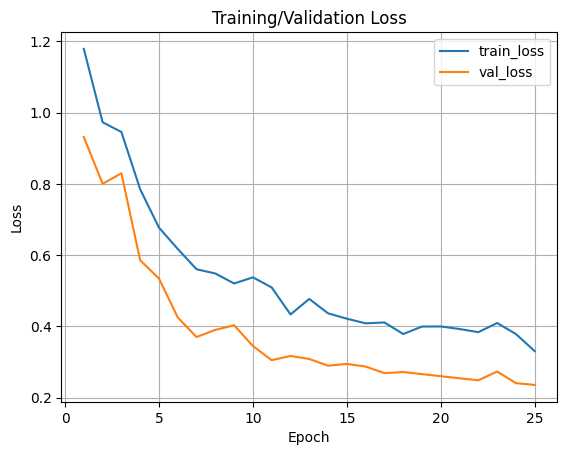

Saved: /content/drive/MyDrive/runs/SkinCancer/loss_curve.png


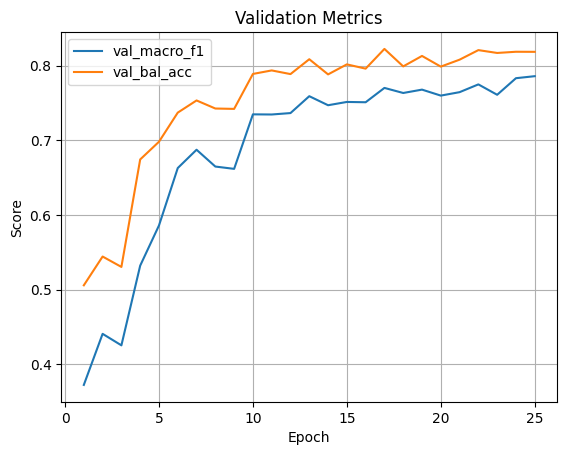

Saved: /content/drive/MyDrive/runs/SkinCancer/val_metrics_curve.png


In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

log_path = os.path.join(RUN_DIR, "train_log.txt")
assert os.path.exists(log_path), f"Không thấy {log_path}"

with open(log_path, "r", encoding="utf-8") as f:
    lines = f.readlines()
pattern = re.compile(
    r"Epoch\s+(\d+)\s+\|\s+train_loss=([0-9.]+)\s+\|\s+val_loss=([0-9.]+)\s+\|\s+val_macro_f1=([0-9.]+)\s+\|\s+val_bal_acc=([0-9.]+)"
)

rows = []
for ln in lines:
    m = pattern.search(ln)
    if m:
        epoch = int(m.group(1))
        train_loss = float(m.group(2))
        val_loss = float(m.group(3))
        val_f1 = float(m.group(4))
        val_bal = float(m.group(5))
        rows.append([epoch, train_loss, val_loss, val_f1, val_bal])

df_hist = pd.DataFrame(rows, columns=["epoch", "train_loss", "val_loss", "val_macro_f1", "val_bal_acc"])
df_hist = df_hist.sort_values("epoch").reset_index(drop=True)
display(df_hist.head(), df_hist.tail())

# Save csv
hist_csv = os.path.join(RUN_DIR, "history.csv")
df_hist.to_csv(hist_csv, index=False)
print("Saved:", hist_csv)

# Plot 1: Loss
plt.figure()
plt.plot(df_hist["epoch"], df_hist["train_loss"], label="train_loss")
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation Loss")
plt.legend()
plt.grid(True)
loss_png = os.path.join(RUN_DIR, "loss_curve.png")
plt.savefig(loss_png, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", loss_png)

# Plot 2: Metrics
plt.figure()
plt.plot(df_hist["epoch"], df_hist["val_macro_f1"], label="val_macro_f1")
plt.plot(df_hist["epoch"], df_hist["val_bal_acc"], label="val_bal_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True)
metrics_png = os.path.join(RUN_DIR, "val_metrics_curve.png")
plt.savefig(metrics_png, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", metrics_png)

Saved: /content/drive/MyDrive/runs/SkinCancer/confusion_matrix.csv


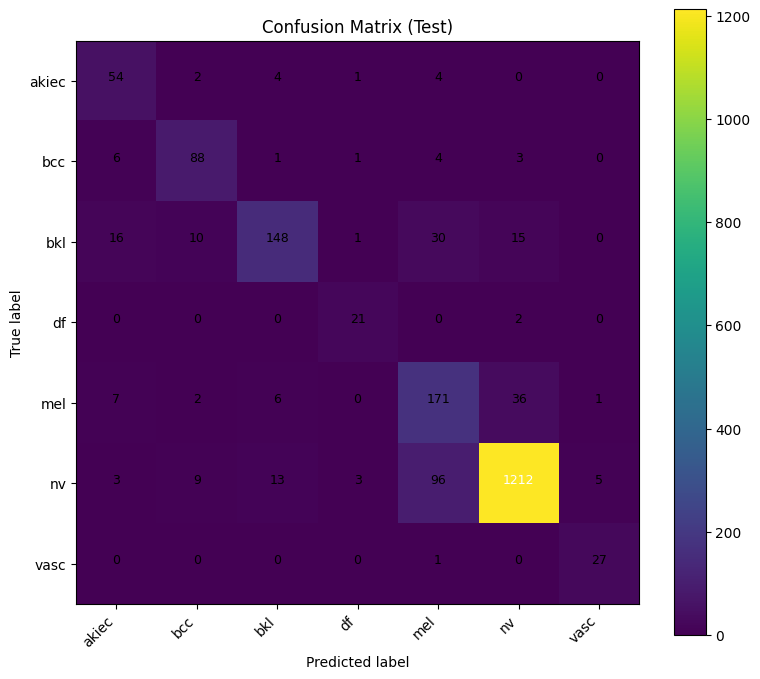

Saved: /content/drive/MyDrive/runs/SkinCancer/confusion_matrix.png
Saved: /content/drive/MyDrive/runs/SkinCancer/classification_report.txt
              precision    recall  f1-score   support

       akiec     0.6279    0.8308    0.7152        65
         bcc     0.7928    0.8544    0.8224       103
         bkl     0.8605    0.6727    0.7551       220
          df     0.7778    0.9130    0.8400        23
         mel     0.5588    0.7668    0.6465       223
          nv     0.9558    0.9038    0.9291      1341
        vasc     0.8182    0.9643    0.8852        28

    accuracy                         0.8592      2003
   macro avg     0.7703    0.8437    0.7991      2003
weighted avg     0.8782    0.8592    0.8645      2003



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true_path = os.path.join(RUN_DIR, "y_true.npy")
y_pred_path = os.path.join(RUN_DIR, "y_pred.npy")

assert os.path.exists(y_true_path) and os.path.exists(y_pred_path), \
    "Không thấy y_true.npy / y_pred.npy trong RUN_DIR. Bạn hãy chạy phần TEST trong code train hoặc báo mình để mình đưa đoạn chạy test lại."

y_true = np.load(y_true_path)
y_pred = np.load(y_pred_path)

ckpt_path = os.path.join(RUN_DIR, "best_model.pt")
class_names = None
if os.path.exists(ckpt_path):
    import torch
    ckpt = torch.load(ckpt_path, map_location="cpu")
    class_names = ckpt.get("class_names", None)
if class_names is None:
    class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)


cm_csv = os.path.join(RUN_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_csv)
print("Saved:", cm_csv)

plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        plt.text(j, i, str(val),
                 horizontalalignment="center",
                 color="white" if val > thresh else "black",
                 fontsize=9)

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

cm_png = os.path.join(RUN_DIR, "confusion_matrix.png")
plt.savefig(cm_png, dpi=250, bbox_inches="tight")
plt.show()
print("Saved:", cm_png)

# Classification report txt
report_txt = classification_report(y_true, y_pred, target_names=class_names, digits=4)
report_path = os.path.join(RUN_DIR, "classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_txt)
print("Saved:", report_path)

print(report_txt)

In [ ]:
import os
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

test_dir = os.path.join("dataset", "test")

if os.path.exists("/content/dataset/test"):
    test_dir = "/content/dataset/test"

dummy_tf = transforms.Compose([transforms.Resize(10), transforms.ToTensor()])
test_ds = datasets.ImageFolder(test_dir, transform=dummy_tf)

paths = [p for (p, _) in test_ds.samples]
true_labels = np.array(test_ds.targets)

assert len(paths) == len(y_true), "Số ảnh test trong folder khác với y_true.npy"

wrong_idx = np.where(y_true != y_pred)[0]

rows = []
for idx in wrong_idx:
    rows.append({
        "path": paths[idx],
        "true_class": class_names[y_true[idx]],
        "pred_class": class_names[y_pred[idx]],
    })

df_wrong = pd.DataFrame(rows)
wrong_csv = os.path.join(RUN_DIR, "misclassified_cases.csv")
df_wrong.to_csv(wrong_csv, index=False)
display(df_wrong.head(20))
print("Saved:", wrong_csv, " | total wrong:", len(df_wrong))

,path,true_class,pred_class
0,/content/dataset/test/akiec/ISIC_0025069.jpg,akiec,mel
1,/content/dataset/test/akiec/ISIC_0025264.jpg,akiec,mel
2,/content/dataset/test/akiec/ISIC_0025539.jpg,akiec,bkl
3,/content/dataset/test/akiec/ISIC_0026132.jpg,akiec,bcc
4,/content/dataset/test/akiec/ISIC_0026549.jpg,akiec,bkl
5,/content/dataset/test/akiec/ISIC_0029598.jpg,akiec,bkl
6,/content/dataset/test/akiec/ISIC_0029915.jpg,akiec,df
7,/content/dataset/test/akiec/ISIC_0030387.jpg,akiec,bcc
8,/content/dataset/test/akiec/ISIC_0031043.jpg,akiec,mel
9,/content/dataset/test/akiec/ISIC_0031191.jpg,akiec,mel


Saved: /content/drive/MyDrive/runs/SkinCancer/misclassified_cases.csv  | total wrong: 282


ROC-AUC (OvR) macro   : 0.9753688833346376
ROC-AUC (OvR) weighted: 0.9657471608026174


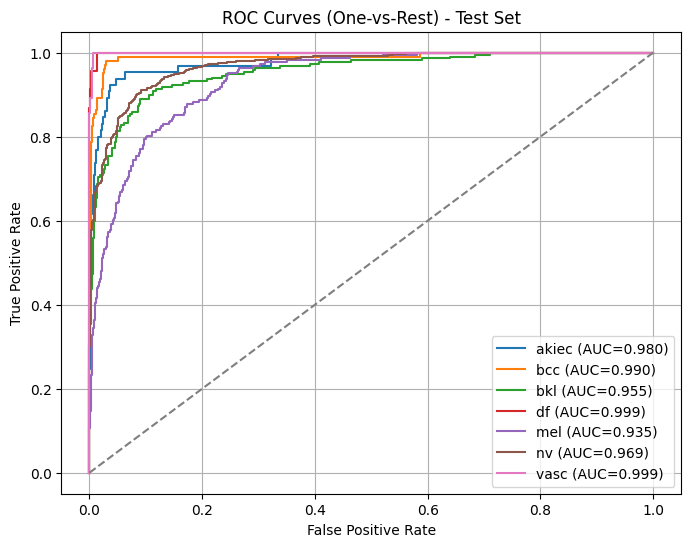

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

RUN_DIR = "/content/drive/MyDrive/runs/SkinCancer"
CKPT_PATH = os.path.join(RUN_DIR, "best_model.pt")

# 1) Load checkpoint + class names
ckpt = torch.load(CKPT_PATH, map_location="cpu")
class_names = ckpt["class_names"]
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Build EfficientNet-B3 like lúc train
weights = models.EfficientNet_B3_Weights.DEFAULT
model = models.efficientnet_b3(weights=weights)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()

# 3) Test dataset (đúng preprocess như val/test)
IMG_SIZE = ckpt["cfg"]["IMG_SIZE"] if "cfg" in ckpt else 300
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

TEST_DIR = "/content/dataset/test"
test_ds = datasets.ImageFolder(TEST_DIR, transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

all_y = []
all_probs = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        all_probs.append(probs)
        all_y.append(y.numpy())

y_true = np.concatenate(all_y)
y_score = np.concatenate(all_probs)

auc_macro = roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_true, y_score, multi_class="ovr", average="weighted")

print("ROC-AUC (OvR) macro   :", auc_macro)
print("ROC-AUC (OvR) weighted:", auc_weighted)

y_onehot = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_onehot[:, i], y_score[:, i])
    auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - Test Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()